In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
def find_glitches(s, t=5):
    return (s.diff().abs() > t) & (s.diff(-1).abs() > t)

def clean_pipeline(df, threshold=5.0):
    df = df.copy()
    for col in ['sensor_temp_main', 'sensor_temp_backup']:
        glitches = find_glitches(df[col], threshold)
        df.loc[glitches, col] = np.nan
        df[col] = df[col].interpolate(method='time', limit_direction='both')
    return df

df_raw = pd.read_csv("datos/dataset_horno_sostenimiento2_CORREGIDO.csv",
                     parse_dates=['timestamp']).set_index('timestamp').sort_index()
df = clean_pipeline(df_raw)
print(f"Muestras: {len(df)}")


Muestras: 20160


In [3]:
FEATURES = ['sensor_temp_main', 'sensor_temp_backup', 'setpoint', 'heater_power_pct',
            'electrical_current', 'electrical_voltage', 'aluminum_level_pct',
            'ambient_temp', 'energy_consumption_kwh', 'lid_open_pct', 'production_draw_rate']

df5 = df[FEATURES].resample('5min').mean().interpolate()
print(f"Muestras tras resample 5 min: {len(df5)}")


Muestras tras resample 5 min: 4032


In [4]:
W = 12
n = len(df5)
i_train = int(n * 0.70)
i_val = int(n * 0.85)

scaler = StandardScaler().fit(df5.iloc[:i_train].values)
X_all = scaler.transform(df5.values)

def make_windows(X, W):
    n = len(X) - W + 1
    out = np.zeros((n, W, X.shape[1]))
    for i in range(n):
        out[i] = X[i:i+W]
    return out

X_train = make_windows(X_all[:i_train], W)
X_val   = make_windows(X_all[i_train:i_val], W)
X_test  = make_windows(X_all[i_val:], W)
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")


X_train: (2811, 12, 11) | X_val: (594, 12, 11) | X_test: (594, 12, 11)


In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden=32, latent=8, window=12):
        super().__init__()
        self.window = window
        self.latent = latent
        self.encoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_features)

    def forward(self, x):
        B = x.size(0)
        _, (h, _) = self.encoder(x)
        z = self.to_latent(h[-1])
        h0 = self.from_latent(z).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        dec_input = h0.transpose(0, 1).repeat(1, self.window, 1)
        out, _ = self.decoder(dec_input, (h0, c0))
        return self.head(out), z

n_features = X_train.shape[2]
model = LSTMAutoencoder(n_features=n_features, hidden=32, latent=8, window=W).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {n_params}")
print(model)


Parámetros: 15123
LSTMAutoencoder(
  (encoder): LSTM(11, 32, batch_first=True)
  (to_latent): Linear(in_features=32, out_features=8, bias=True)
  (from_latent): Linear(in_features=8, out_features=32, bias=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=11, bias=True)
)


In [6]:
X_tr_t = torch.FloatTensor(X_train).to(device)
X_va_t = torch.FloatTensor(X_val).to(device)
X_te_t = torch.FloatTensor(X_test).to(device)

train_loader = DataLoader(TensorDataset(X_tr_t), batch_size=128, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()

EPOCHS = 15
history = {'train': [], 'val': []}
for ep in range(1, EPOCHS+1):
    model.train()
    losses = []
    for (xb,) in train_loader:
        optimizer.zero_grad()
        recon, _ = model(xb)
        loss = loss_fn(recon, xb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        recon_v, _ = model(X_va_t)
        val_loss = loss_fn(recon_v, X_va_t).item()
    history['train'].append(np.mean(losses))
    history['val'].append(val_loss)
    print(f"ep {ep:2d}: train MAE={history['train'][-1]:.4f}  val MAE={history['val'][-1]:.4f}")


ep  1: train MAE=0.7885  val MAE=0.6922
ep  2: train MAE=0.6563  val MAE=0.4942


ep  3: train MAE=0.4752  val MAE=0.4466
ep  4: train MAE=0.4357  val MAE=0.4306


ep  5: train MAE=0.4127  val MAE=0.3947
ep  6: train MAE=0.3830  val MAE=0.3625


ep  7: train MAE=0.3564  val MAE=0.3226
ep  8: train MAE=0.3230  val MAE=0.2867


ep  9: train MAE=0.2901  val MAE=0.2595
ep 10: train MAE=0.2605  val MAE=0.2389


ep 11: train MAE=0.2338  val MAE=0.2259
ep 12: train MAE=0.2160  val MAE=0.2146


ep 13: train MAE=0.2037  val MAE=0.2071
ep 14: train MAE=0.1952  val MAE=0.2028


ep 15: train MAE=0.1889  val MAE=0.1975


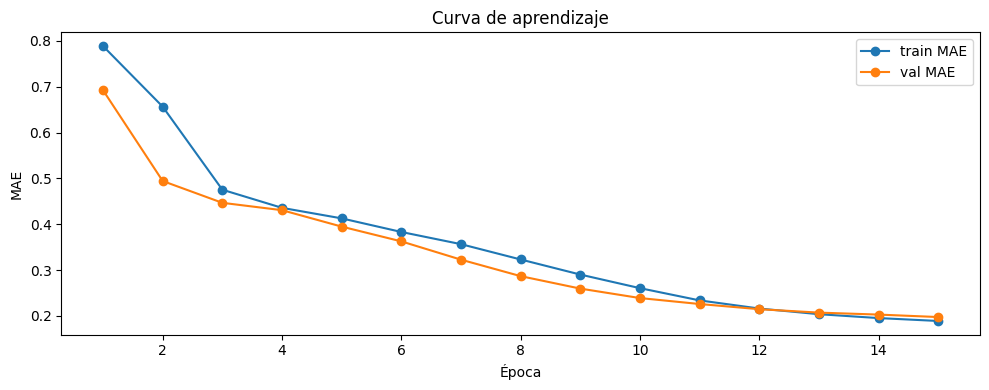

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS+1), history['train'], 'o-', label='train MAE')
ax.plot(range(1, EPOCHS+1), history['val'], 'o-', label='val MAE')
ax.set_xlabel('Época'); ax.set_ylabel('MAE')
ax.set_title('Curva de aprendizaje')
ax.legend(); plt.tight_layout(); plt.show()


In [8]:
model.eval()
with torch.no_grad():
    recon_te, z_te = model(X_te_t)
recon_te_np = recon_te.cpu().numpy()
X_te_np = X_te_t.cpu().numpy()
z_te_np = z_te.cpu().numpy()

err_per_window = np.mean((recon_te_np - X_te_np)**2, axis=(1, 2))
print(f"MSE reconstrucción test: media={err_per_window.mean():.4f} | mediana={np.median(err_per_window):.4f}")
print(f"Espacio latente shape: {z_te_np.shape}")


MSE reconstrucción test: media=0.3768 | mediana=0.0264
Espacio latente shape: (594, 8)


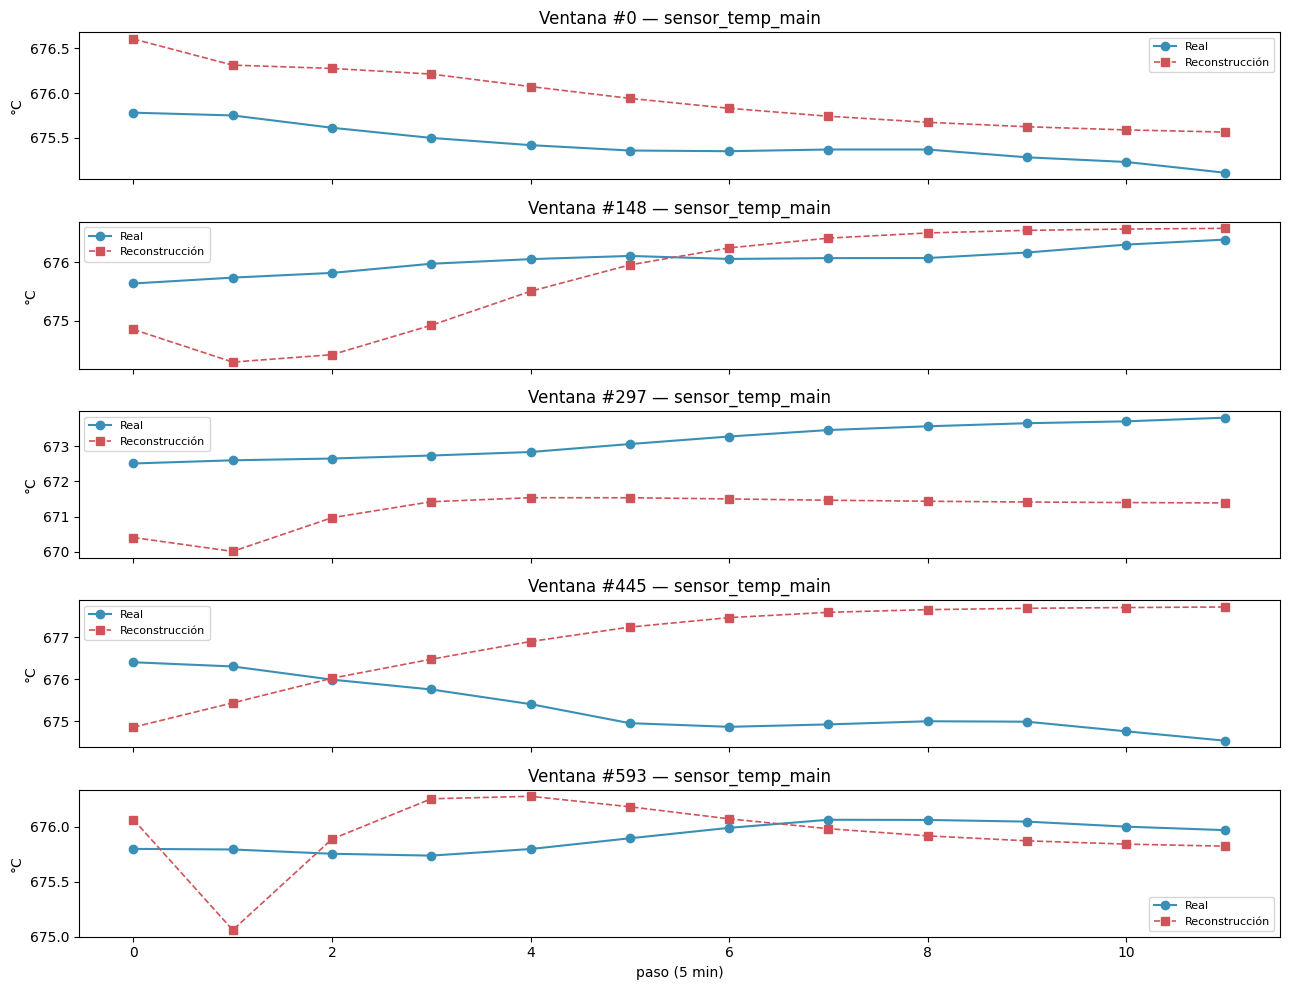

In [9]:
idx_sample = [0, len(X_te_np)//4, len(X_te_np)//2, len(X_te_np)*3//4, len(X_te_np)-1]
feat_idx = FEATURES.index('sensor_temp_main')

fig, axes = plt.subplots(len(idx_sample), 1, figsize=(13, 10), sharex=True)
for ax, i in zip(axes, idx_sample):
    real = scaler.inverse_transform(X_te_np[i])[:, feat_idx]
    recon = scaler.inverse_transform(recon_te_np[i])[:, feat_idx]
    ax.plot(real, 'o-', color='#3a8fb7', lw=1.5, label='Real')
    ax.plot(recon, 's--', color='#cf545a', lw=1.2, label='Reconstrucción')
    ax.set_title(f'Ventana #{i} — sensor_temp_main')
    ax.set_ylabel('°C'); ax.legend(fontsize=8)
axes[-1].set_xlabel('paso (5 min)')
plt.tight_layout(); plt.show()


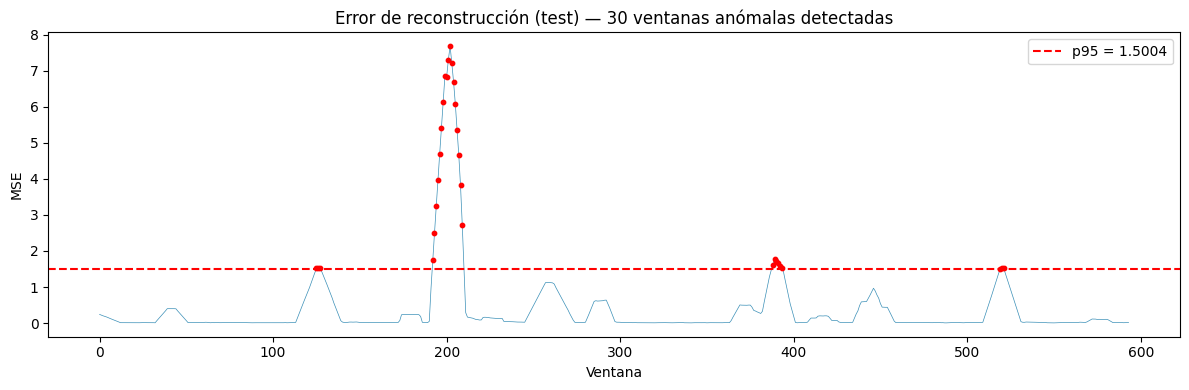

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(err_per_window, lw=0.5, color='#3a8fb7')
threshold = np.percentile(err_per_window, 95)
ax.axhline(threshold, color='red', ls='--', label=f'p95 = {threshold:.4f}')
anom_idx = np.where(err_per_window > threshold)[0]
ax.scatter(anom_idx, err_per_window[anom_idx], color='red', s=10, zorder=5)
ax.set_title(f'Error de reconstrucción (test) — {len(anom_idx)} ventanas anómalas detectadas')
ax.set_xlabel('Ventana'); ax.set_ylabel('MSE')
ax.legend(); plt.tight_layout(); plt.show()


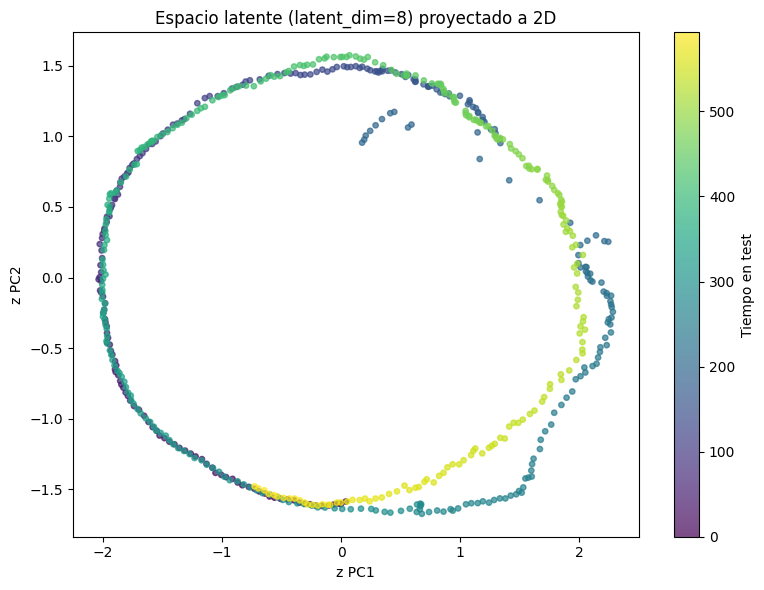

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit_transform(z_te_np)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(pca[:, 0], pca[:, 1], c=np.arange(len(pca)), cmap='viridis', s=15, alpha=0.7)
plt.colorbar(sc, label='Tiempo en test')
ax.set_xlabel('z PC1'); ax.set_ylabel('z PC2')
ax.set_title(f'Espacio latente (latent_dim={z_te_np.shape[1]}) proyectado a 2D')
plt.tight_layout(); plt.show()


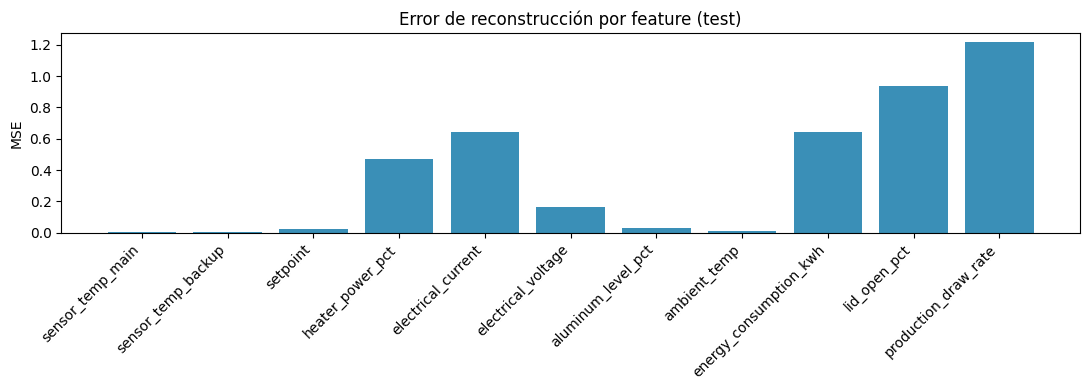

In [12]:
err_per_feature = np.mean((recon_te_np - X_te_np)**2, axis=(0, 1))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(FEATURES)), err_per_feature, color='#3a8fb7')
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right')
ax.set_ylabel('MSE'); ax.set_title('Error de reconstrucción por feature (test)')
plt.tight_layout(); plt.show()


In [13]:
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'features': FEATURES,
    'window': W,
    'latent_dim': model.latent,
}, 'salidas/autoencoder_baseline.pt')
print("OK: autoencoder_baseline.pt guardado")


OK: autoencoder_baseline.pt guardado
